In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

In [26]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
print("=== [SECTION 1] Baseline Logistic Regression ===")
baseline_lr = LogisticRegression(max_iter=1000)
baseline_lr.fit(X_train_scaled, y_train)
y_pred_lr = baseline_lr.predict(X_test_scaled)
y_prob_lr = baseline_lr.predict_proba(X_test_scaled)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

=== [SECTION 1] Baseline Logistic Regression ===

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



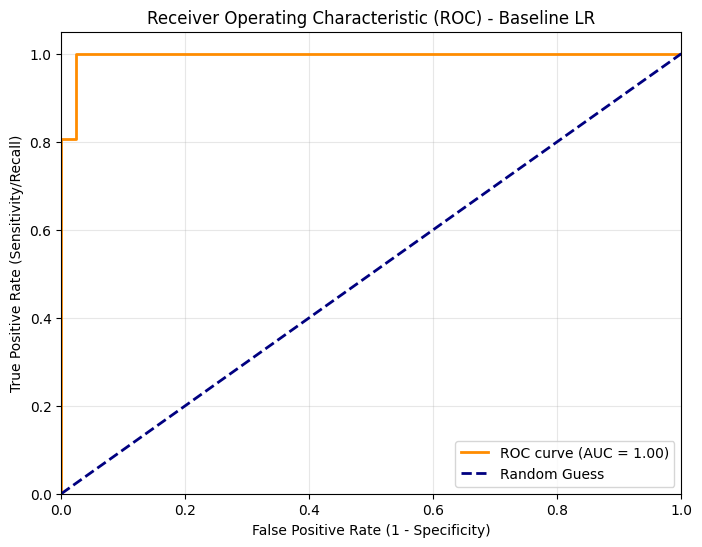

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) - Baseline LR')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [31]:

print("\n=== [SECTION 2] Logistic Regression (Balanced Class Weights) ===")

balanced_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
balanced_lr.fit(X_train_scaled, y_train)
y_pred_balanced = balanced_lr.predict(X_test_scaled)
print("\nClassification Report (Balanced):")
print(classification_report(y_test, y_pred_balanced, target_names=class_names))



=== [SECTION 2] Logistic Regression (Balanced Class Weights) ===

Classification Report (Balanced):
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [32]:
print("\n=== [SECTION 3] Decision Tree Classifier (Comparison) ===")
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_scaled, y_train)
y_pred_dt = dt_clf.predict(X_test_scaled)

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=class_names))

train_acc = dt_clf.score(X_train_scaled, y_train)
test_acc = dt_clf.score(X_test_scaled, y_test)
print(f"\nDecision Tree Training Accuracy: {train_acc:.4f}")
print(f"Decision Tree Testing Accuracy: {test_acc:.4f}")


=== [SECTION 3] Decision Tree Classifier (Comparison) ===

Classification Report (Decision Tree):
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114


Decision Tree Training Accuracy: 1.0000
Decision Tree Testing Accuracy: 0.9123
